# X7: Stellar-origin black-hole binaries — a standalone MCMC

**Development-stack exercise notebook (LATW `dev` branch).** There is no
Colab button: these exercises target the *development* versions of the LISA
Analysis Tools packages. Set the environment up by cloning LISAanalysistools
and running its installer (it lays every sibling repo out side by side and
editable-installs the development branches):

```bash
git clone https://github.com/lisa-analysis-tools/lisa-analysis-tools.git LISAanalysistools
bash LISAanalysistools/install.sh
```

For the workshop on the **pip-released** packages, use the
[`main` branch](https://github.com/lisa-analysis-tools/LATW/tree/main) instead
(branch policy: `main` &harr; pip releases, `dev` &harr; the `install.sh` stack).

In [1]:
import os

# Threading is pinned to 1 everywhere in this workshop (MPI-only policy;
# OMP-threaded kernels have caused out-of-memory kills on laptops).
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")

import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from copy import deepcopy
from lisatools.utils.constants import *

# Eryn's internals still import a legacy prior module (harmless) and the stock
# noise models divide by f = 0 on full grids; silence both so output stays clean.
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

This exercise takes a **new source** — a *stellar-origin black-hole binary*
(SOBHB) — through the very same **source-MCMC skeleton** you built for the
galactic binary in [`X6`](X6_GalacticBinaryMCMC.ipynb). SOBHBs are the
LISA-band *early inspiral* of the ~10–100 M⊙ black-hole binaries that
LIGO/Virgo later hear merge: years to decades before coalescence they radiate
at a few mHz, deep in the LISA band, as **quiet, nearly monochromatic, slowly
chirping** tones. We build the stock waveform, plot it, measure its SNR, and
run a short tempered MCMC to recover a few of its parameters.

The waveform is the documented `all_sources` SOBHB default —
[`build_sobbh_stock_waveform`](https://lisa-analysis-tools.github.io/lisa-analysis-tools)
(a 3.5&thinsp;PN aligned-spin inspiral projected through the **TDI-on-the-fly**
LISA response, in **XYZ**). The companion informational notebooks are
[`06` &sect; SOBHB](../../06_SourceWaveforms.ipynb) (the waveform),
[`05` &sect; Response](../../05_ResponseAndTDI.ipynb) (TDI-on-the-fly), and
[`07`](../../07_ErynSmallToLarge.ipynb) (Eryn). Everything is on the laptop CPU.

> **Heads-up on cost.** On a laptop CPU the on-the-fly SOBHB generator costs a
> *few seconds per template*, so the MCMC below is deliberately **tiny** — a
> proof of concept that is **explicitly not converged**. A real SOBHB analysis
> runs on the GPU (and/or the signal-heterodyne likelihood) for the millions of
> template evaluations it needs.

### How these exercises work

Each exercise is one of two kinds:

- **Task N** — you *write code* toward a stated goal. In this answer notebook the
  solution cells are filled in; in the generated student notebook they are blanked
  (a whole cell, or just the key solution lines for a fill-in-the-blank). Every
  Task ends with a **Useful documentation:** list pointing at the Sphinx/Eryn API
  docs and the relevant informational-notebook section.
- **Question** (a `### Question` heading) — a short *discussion* prompt. No code
  required; the answer sketch here is for the group conversation.

The tasks build on each other in order, so run them top to bottom.

### The source-MCMC skeleton (again)

Every source in the LISA global fit is sampled with the **same skeleton** — the
one you already ran for a GB in [`X6`](X6_GalacticBinaryMCMC.ipynb). The whole
point of this notebook is that swapping *source type* changes **only the
waveform**; the data container, likelihood, and sampler are identical:

- **Stage A — Data** (Tasks 1–2): synthesize an injected XYZ data stream (a
  single SOBHB on a short grid), band-limit it, and read off the optimal SNR.
- **Stage B — Template generator** (Task 3): a `signal_gen(*params) -> DomainBase`
  closure that builds a band-limited SOBHB template.
- **Stage C — Likelihood** (Task 4): an `AnalysisContainer(data, sens, signal_gen)`
  whose `eryn_likelihood_function` is the sampler's log-likelihood.
- **Stage D — Sample** (Task 5): Eryn priors + a tempered `EnsembleSampler`, a
  short run, a corner plot against the truth.

An EMRI or an MBHB is *the same sampler with a different `signal_gen`*.

## Task 1: Build a SOBHB waveform and look at it (Stage A)

**The physics.** A stellar-origin black-hole binary is the LISA-band *early
inspiral* of the same ~10–100 M⊙ black-hole binary a ground detector later
hears merge. Years to decades before coalescence it orbits at a few mHz, deep
in the LISA band, radiating a nearly **monochromatic** tone that sweeps *upward*
in frequency so slowly ($\dot f \propto f^{11/3}$ is tiny at mHz) that over a
short observation it looks like a single line with a gentle **chirp**. Each one
is **individually quiet** — optimal SNR of order a few over the mission — but a
whole population threads the LISA band. LISA catches them in the low-frequency
inspiral; the same binaries cross into the LIGO/Virgo/ET band and merge years
later, which makes SOBHBs the archetypal **multiband** gravitational-wave source.

Build the stock waveform with
[`build_sobbh_stock_waveform`](https://lisa-analysis-tools.github.io/lisa-analysis-tools)
on the provided short grid (the cell after this one sets up the grid, the
[`TDSettings`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/domains.html)
data domain, the band-limited
[`FDSettings`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/domains.html#lisatools.domains.FDSettings)
analysis domain, the
[`TDIConfig`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/response.html),
and the truth parameters). Then **evaluate** it — the builder returns a callable
on the 11-parameter SOBHB waveform basis and yields a `DomainBase` signal
directly — and **plot** the XYZ TDI channels, both as a time-domain zoom (the
mHz carrier) and as a frequency-domain line (the narrow, slightly broadened
band = the chirp).

Useful documentation:
* [`build_sobbh_stock_waveform`](https://lisa-analysis-tools.github.io/lisa-analysis-tools) (the stock all_sources SOBHB waveform; TDI-on-the-fly, XYZ)
* [`TDSettings`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/domains.html) /
  [`FDSettings`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/domains.html#lisatools.domains.FDSettings) /
  [`TDIConfig`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/response.html)
* Informational notebook: see [`06` &sect; SOBHB](../../06_SourceWaveforms.ipynb) and [`05` &sect; Response](../../05_ResponseAndTDI.ipynb)

In [2]:
# imports
from lisatools.sources.sobbh.response import build_sobbh_stock_waveform
from lisatools.domains import TDSettings, FDSettings, FDSignal
from lisatools.response.tdiconfig import TDIConfig
from lisatools.sensitivity import XYZ2SensitivityMatrix
from lisatools.analysiscontainer import AnalysisContainer
from scipy.signal.windows import tukey

In [3]:
# provided "data processor": the grid, domains, and injection truth. Run as-is.
# --- a short, laptop-cheap grid -------------------------------------------
dt = 15.0                       # cadence [s]  (Nyquist 1/2dt = 33 mHz, far above the source)
N = 2 ** 16                     # 65536 time samples  (rFFT length N//2 + 1)
Tobs = N * dt                   # observation span (~11 days)
df = 1.0 / Tobs                 # frequency resolution
t_start = 0.0
t_arr = np.arange(N) * dt + t_start
print(f"Tobs = {Tobs / 86400:.1f} days   dt = {dt:.0f} s   df = {df:.2e} Hz   rFFT length = {N // 2 + 1}")

# The SOBHB sits in a narrow band around f_low; this is the band we score on.
F_LOW = 8.0e-3                                    # starting GW frequency [Hz]
band = (F_LOW - 3.0e-4, F_LOW + 8.0e-4)           # room for the (slow) upward chirp

td_settings = TDSettings(N=N, dt=dt, t0=t_start, force_backend="cpu")
fd_band = FDSettings(N=N // 2 + 1, df=df, min_freq=band[0], max_freq=band[1],
                     force_backend="cpu")
tdi_config = TDIConfig("2nd generation")          # matches the global fit
window = tukey(N, alpha=0.1)                       # taper before the FD projection

# Truth in the 11-parameter SOBHB *waveform* basis:
#   (m1, m2, s1, s2, dist[Gpc], inc, f_low, ra, dec, psi, phi0)
# We only *sample* (m1, m2, dist) later; the rest are held fixed at truth.
M1, M2 = 40.0, 35.0            # component masses [Msun]
S1, S2 = 0.0, 0.0             # aligned spins
DIST = 0.018                  # luminosity distance [Gpc] (a nearby, loud example)
INC = 0.6                     # inclination [rad]
RA, DEC, PSI, PHI0 = 4.0, 0.3, 1.0, 0.5   # sky (orbit frame), polarization, ref phase
truth = (M1, M2, S1, S2, DIST, INC, F_LOW, RA, DEC, PSI, PHI0)

Mc = (M1 * M2) ** 0.6 / (M1 + M2) ** 0.2
print(f"total mass = {M1 + M2:.0f} Msun   chirp mass Mc = {Mc:.2f} Msun")

Tobs = 11.4 days   dt = 15 s   df = 1.02e-06 Hz   rFFT length = 32769
total mass = 75 Msun   chirp mass Mc = 32.56 Msun


FD signal: FDSignal (3, 1081)  TD signal: (3, 65536)


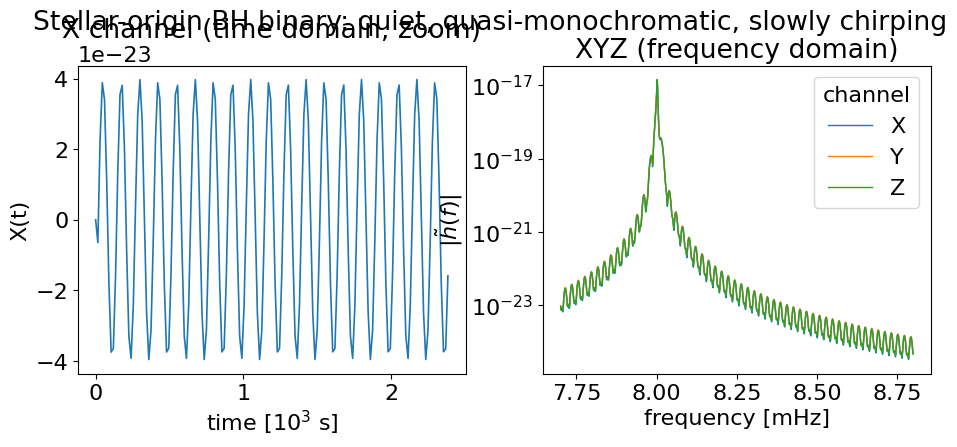

In [4]:
# clear
# build THE stock all_sources SOBHB waveform (TDI-on-the-fly, XYZ) and evaluate it.
# n_grid=256 shrinks the (smooth) PN amp/phase spline for a cheaper laptop template.
wave = build_sobbh_stock_waveform(
    Tobs=Tobs, dt=dt, t_start=t_start,
    td_settings=td_settings, target_domain=fd_band,
    tdi_config=tdi_config, n_grid=256, force_backend="cpu",
    td_window=window, nchannels=3)

h_fd = wave(*truth)                 # an FDSignal already on the analysis band
h_td = wave.raw_td(*truth)          # the (3, N) time-domain XYZ TDI on the data grid
print("FD signal:", type(h_fd).__name__, np.asarray(h_fd.arr).shape,
      " TD signal:", h_td.shape)

fb = np.asarray(fd_band.f_arr)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4))
# left: time-domain zoom on the mHz carrier (a few dozen cycles)
nz = 160
ax0.plot(t_arr[:nz] / 1e3, h_td[0, :nz], color="C0", lw=1.2)
ax0.set(xlabel=r"time [$10^3$ s]", ylabel="X(t)", title="X channel (time domain, zoom)")
# right: frequency-domain — a narrow, slightly broadened line (the chirp)
for lab, i, c in zip("XYZ", range(3), ("C0", "C1", "C2")):
    ax1.semilogy(fb * 1e3, np.abs(np.asarray(h_fd.arr[i])), color=c, lw=1.0, label=lab)
ax1.set(xlabel="frequency [mHz]", ylabel=r"$|\tilde h(f)|$",
        title="XYZ (frequency domain)")
ax1.legend(title="channel")
fig.suptitle("Stellar-origin BH binary: quiet, quasi-monochromatic, slowly chirping", y=1.02)
plt.show()

### Question: how is a SOBHB different from a GB and an MBHB?

You have now seen all three "compact-binary" tones in the LISA band. In one
sentence each: how does a SOBHB differ from a **galactic binary** (X6) and from
a **massive black-hole binary** (the loud chirp-merger of `05`)?

*Discussion.* A **galactic binary** is a white-dwarf pair so far from merger that
its frequency is essentially *fixed* over the mission — a pure monochromatic line
(the tiny `fdot` is often unmeasurable). A **SOBHB** is the same idea one rung up
in mass and closer to merger: still a narrow line, but now with a *measurable
chirp* — over years it sweeps visibly upward in frequency, and it will eventually
leave the LISA band entirely. A **massive black-hole binary** is at the opposite
extreme: it sweeps through the whole LISA band and **merges within the
observation**, producing a loud inspiral–merger–ringdown chirp with SNR in the
hundreds to thousands. So the three are the same physics (a chirping binary) seen
at three points on the frequency-evolution ladder: GB = frozen, SOBHB = slow
chirp / **no merger in band**, MBHB = full chirp *and* merger. That also orders
their loudness: MBHBs are individually the loudest, GBs and SOBHBs are quiet and
must be dug out of the data (and, for GBs, out of their own confusion foreground).

## Task 2: The injected SNR (Stage A, continued)

The waveform you just built *is* the injected data (a single SOBHB in otherwise
empty XYZ, so the truth is exact). Pair it with the matching noise covariance and
read off the **optimal SNR**, exactly as in [`X1`](X1_SensitivitySNR.ipynb) and
[`X6`](X6_GalacticBinaryMCMC.ipynb): build an
[`XYZ2SensitivityMatrix`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/sensitivity.html#lisatools.sensitivity.XYZ2SensitivityMatrix)
on the same band, drop it with the signal into an
[`AnalysisContainer`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/datacontainer.html#analysis-container),
and call `.snr()`.

Useful documentation:
* [`XYZ2SensitivityMatrix`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/sensitivity.html#lisatools.sensitivity.XYZ2SensitivityMatrix) /
  [`AnalysisContainer`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/datacontainer.html#analysis-container) /
  [`.snr`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/datacontainer.html)
* Informational notebook: see [`04` &sect; the `AnalysisContainer`](../../04_Foundations.ipynb) and [`X1`](X1_SensitivitySNR.ipynb)

In [5]:
# clear
# the noise covariance on the band + the analysis atom (X1), then the SNR
sens = XYZ2SensitivityMatrix(fd_band, model="sangria")
ac_data = AnalysisContainer(h_fd, sens)                 # data + covariance
print("band bins:", np.asarray(fd_band.f_arr).size)
print(f"injected optimal SNR = {ac_data.snr():.2f}")

band bins: 1081
injected optimal SNR = 19.11


### Question: what does LISA actually measure for a SOBHB?

The SNR you just printed is modest (this is a *nearby, loud* example; a typical
SOBHB is quieter still). Given that LISA only ever sees the slow low-frequency
inspiral — never the merger — what does it actually *measure*, and why are
SOBHBs so scientifically valuable?

*Discussion.* LISA measures the **early inspiral**: a long, coherent, slowly
chirping tone. From the accumulated phase it pins down the **chirp mass** (the
combination that sets the chirp rate) superbly, and from the slow amplitude
modulation as LISA orbits the Sun it localizes the source on the sky and measures
distance/inclination. Crucially, the measured chirp rate is a *clock*: it predicts
**when** (years to decades ahead) and **at what frequency** the binary will enter
the ground-based band and merge. That is the promise of **multiband** GW
astronomy — LISA issues an early-warning alert and a sky map, ground detectors
(LIGO/Virgo/ET/CE) catch the merger, and the two together span ~4 decades of
frequency on *one* source: unrivalled tests of GR, of BH formation channels, and
of the binary's eccentricity and environment. LISA is the *fore*sight; the ground
network is the *hind*sight.

## Task 3: A band-limited template generator (Stage B)

The sampler needs to build a *template* for any trial parameter set. As with the
GB in [`X6`](X6_GalacticBinaryMCMC.ipynb), the SOBHB lives in a **narrow band**,
so we generate and score it only on `fd_band` (a thousand bins instead of the
whole Nyquist grid). Wrap the stock waveform in a closure over the **sampled**
parameters — here just `(m1, m2, dist)` — that fills the fixed parameters at
truth and returns the band-limited `FDSignal`. (We hold the spins, `f_low`, sky,
polarization, inclination, and phase fixed to keep the demo cheap; the real
pipeline samples all eleven.)

Useful documentation:
* [`build_sobbh_stock_waveform`](https://lisa-analysis-tools.github.io/lisa-analysis-tools) (11-param basis `(m1, m2, s1, s2, dist, inc, f_low, ra, dec, psi, phi0)`; see [`06` &sect; SOBHB](../../06_SourceWaveforms.ipynb))
* [`FDSignal`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/domains.html#lisatools.domains.FDSignal)
* Informational notebook: see [`06` &sect; SOBHB](../../06_SourceWaveforms.ipynb)

In [6]:
# imports
from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.priors import ProbDistContainer, UniformDistribution

In [7]:
def sobbh_signal_gen(m1, m2, dist):
    """Band-limited XYZ SOBHB template in the sampled 3-parameter basis."""
    # fill the fixed parameters and return the stock waveform on fd_band
    return wave(m1, m2, S1, S2, dist, INC, F_LOW, RA, DEC, PSI, PHI0)  # clear-line

# quick check: the generator reproduces the injection at the truth
_chk = sobbh_signal_gen(M1, M2, DIST)
print("template shape:", tuple(np.asarray(_chk.arr).shape))

template shape: (3, 1081)


## Task 4: Assemble the likelihood (Stage C)

Combine the data, the noise covariance, and the generator into one
`AnalysisContainer`. With `signal_gen=` set, the container exposes
[`eryn_likelihood_function`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/datacontainer.html):
give it a parameter vector, it builds the template and returns
$\ln\mathcal{L} = -\tfrac12\langle d-h\,|\,d-h\rangle$. We set
`likelihood_source_only=True` so the read-out is the clean source term. Confirm
$\ln\mathcal{L}\approx 0$ at the truth (the residual vanishes) and that a small
mass offset drops it.

Useful documentation:
* [`AnalysisContainer`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/datacontainer.html#analysis-container) /
  [`eryn_likelihood_function`](https://lisa-analysis-tools.github.io/lisa-analysis-tools/user/datacontainer.html)
* Informational notebook: see [`07` &sect; The lisatools sampler layer](../../07_ErynSmallToLarge.ipynb) and [`X1`](X1_SensitivitySNR.ipynb)

In [8]:
# clear
# the likelihood: data + covariance + the band-limited generator
ac = AnalysisContainer(h_fd, sens, signal_gen=sobbh_signal_gen,
                       likelihood_source_only=True)

truth3 = np.array([M1, M2, DIST])
print(f"logL(truth)        = {ac.eryn_likelihood_function(truth3): .4e}")
# nudging m1 by 2 Msun dephases the chirp and drops the likelihood
off = truth3 + np.array([2.0, 0.0, 0.0])
print(f"logL(m1 + 2 Msun)  = {ac.eryn_likelihood_function(off): .4e}")

logL(truth)        =  2.8422e-13


logL(m1 + 2 Msun)  = -9.1390e+00


## Task 5: Priors, a tempered sampler, and a corner plot (Stage D)

Now sample. Build a prior with
[`ProbDistContainer`](https://lisa-analysis-tools.github.io/Eryn/user/prior.html#eryn.prior.ProbDistContainer)
of one
[`UniformDistribution`](https://lisa-analysis-tools.github.io/Eryn/user/prior.html)
per parameter, run a **tempered**
[`EnsembleSampler`](https://lisa-analysis-tools.github.io/Eryn/user/ensemble.html#eryn.ensemble.EnsembleSampler)
(the affine-invariant stretch move, with a small temperature ladder), and — as in
a real pipeline that seeds from a *search* — start the walkers in a **tight ball
around the injection**. Because each template costs a few seconds on CPU, this
run is intentionally minimal (a handful of steps); it is a demonstration, not a
converged posterior.

Useful documentation:
* [`EnsembleSampler`](https://lisa-analysis-tools.github.io/Eryn/user/ensemble.html#eryn.ensemble.EnsembleSampler) /
  [`run_mcmc`](https://lisa-analysis-tools.github.io/Eryn/user/ensemble.html) /
  [`State`](https://lisa-analysis-tools.github.io/Eryn/user/state.html)
* [`ProbDistContainer`](https://lisa-analysis-tools.github.io/Eryn/user/prior.html#eryn.prior.ProbDistContainer) /
  [`UniformDistribution`](https://lisa-analysis-tools.github.io/Eryn/user/prior.html)
* Informational notebook: see [`07` &sect; A fixed-dimension ensemble sampler](../../07_ErynSmallToLarge.ipynb) and [`X3`](X3_FixedDimMCMC.ipynb)

In [9]:
# clear
# one uniform prior per sampled parameter: [m1, m2, dist]
priors = ProbDistContainer({
    0: UniformDistribution(30.0, 55.0),     # m1 [Msun]
    1: UniformDistribution(25.0, 50.0),     # m2 [Msun]
    2: UniformDistribution(0.008, 0.05),    # luminosity distance [Gpc]
})

# stretch move needs nwalkers >= 2 * ndim; keep the run tiny (CPU: ~seconds/template)
ntemps, nwalkers, ndim = 2, 6, 3
sampler = EnsembleSampler(nwalkers, ndim, ac.eryn_likelihood_function, priors,
                          tempering_kwargs=dict(ntemps=ntemps))

# tight starting ball around the injection (a search would provide this)
np.random.seed(2026)
scales = np.array([0.8, 0.8, 0.0015])
start = truth3[None, None, None, :] + scales * np.random.randn(ntemps, nwalkers, 1, ndim)

t0 = time.perf_counter()
sampler.run_mcmc(State(start), 5, burn=1, progress=False)
print(f"sampled in {time.perf_counter() - t0:.0f} s")

# cold chain -> (nsteps * nwalkers, ndim)
samples = sampler.get_chain()["model_0"][:, 0, :, 0, :].reshape(-1, ndim)
print("cold samples   :", samples.shape[0])
print("posterior mean :", samples.mean(0))
print("injected truth :", truth3)
print("acceptance     :", np.asarray(sampler.acceptance_fraction).mean().round(3))

sampled in 419 s
cold samples   : 30
posterior mean : [3.97984149e+01 3.53584103e+01 1.77400470e-02]
injected truth : [4.0e+01 3.5e+01 1.8e-02]
acceptance     : 0.65


> **This chain is deliberately tiny and NOT converged.** With only a handful of
> recorded steps and six walkers, the marginals are noisy and seed-dependent — a
> real SOBHB analysis needs *orders of magnitude* more samples (and the GPU /
> signal-heterodyne likelihood to afford them), with tuned proposals and a
> convergence check (autocorrelation time / Gelman–Rubin; see
> [`X3` &sect; Task 4](X3_FixedDimMCMC.ipynb)). We plot it anyway to watch the
> posterior form around the truth.

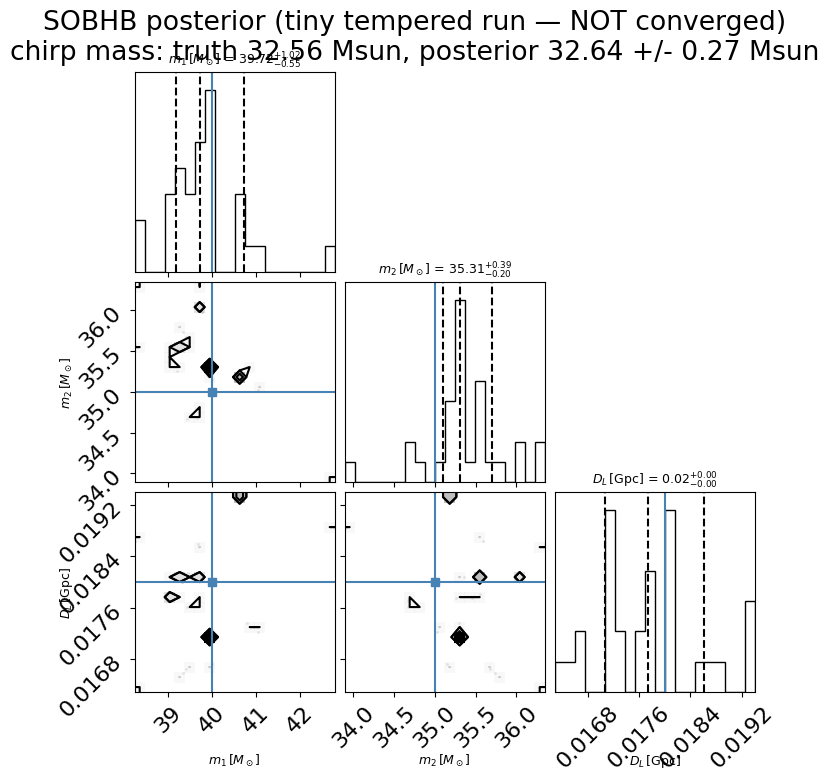

In [10]:
# clear
import corner
Mc_true = (M1 * M2) ** 0.6 / (M1 + M2) ** 0.2
Mc_post = (samples[:, 0] * samples[:, 1]) ** 0.6 / (samples[:, 0] + samples[:, 1]) ** 0.2
labels = [r"$m_1\,[M_\odot]$", r"$m_2\,[M_\odot]$", r"$D_L\,[\mathrm{Gpc}]$"]
fig = corner.corner(samples, labels=labels, truths=truth3,
                    show_titles=True, title_kwargs={"fontsize": 9},
                    label_kwargs={"fontsize": 9}, quantiles=[0.16, 0.5, 0.84])
fig.suptitle(f"SOBHB posterior (tiny tempered run — NOT converged)\n"
             f"chirp mass: truth {Mc_true:.2f} Msun, "
             f"posterior {Mc_post.mean():.2f} +/- {Mc_post.std():.2f} Msun", y=1.03)
plt.show()

### Question: SOBHB parameter degeneracies

Look at the `m1`–`m2` panel. Even in this tiny run the two masses are *not*
independently pinned — they trade off along a ridge. Why? And what other SOBHB
parameters are degenerate?

*Discussion.* The inspiral phase is governed almost entirely by the **chirp
mass** $\mathcal{M}=(m_1 m_2)^{3/5}/(m_1+m_2)^{1/5}$: it sets the chirp rate, and
the long coherent phase makes it exquisitely measurable — which is exactly why
the posterior mean of $\mathcal{M}$ above sits essentially on the truth even
though the run is tiny. But the *individual* masses (equivalently, the mass
ratio) enter only at higher post-Newtonian order and through spin–mass couplings,
so $m_1$ and $m_2$ are poorly separated: the posterior stretches along a curve of
**near-constant $\mathcal{M}$**, the ridge you see. Breaking it needs either
higher SNR / a longer baseline (more inspiral phase to resolve the higher-order
terms) or the eventual merger — which LISA never sees, so for SOBHBs the
mass-ratio and spins stay loosely constrained. Separately, **distance** is a pure
*amplitude* parameter here (we froze the inclination): free it, and $D_L$,
inclination, and polarization open the same **distance–inclination** degeneracy
you met as the GB's $A$–$\iota$ banana in [`X6`](X6_GalacticBinaryMCMC.ipynb),
broken only by LISA's year-long amplitude modulation. So a SOBHB gives you a
razor-sharp chirp mass, a decent sky position and distance, and only weak
individual masses/spins.

### Where this goes next

You just ran the full **source-MCMC skeleton** on a brand-new source — a
stellar-origin black-hole binary — and it was the *same* skeleton as the GB in
[`X6`](X6_GalacticBinaryMCMC.ipynb): only `signal_gen` changed. That is the
punchline of the whole `further/` source series: EMRIs, SOBHBs, MBHBs, and GBs
are one sampler with four waveforms. The leap to the full LISA global fit is
scale — the GPU / signal-heterodyne likelihood to afford millions of these
templates, tuned proposals, reversible jump over source counts
([`X5`](X5_RJMCMC.ipynb)), and all four source types sharing one data stream
(informational notebooks [`07`](../../07_ErynSmallToLarge.ipynb) and
[`03`](../../03_StockGlobalFitsInDepth.ipynb)) — not a new idea about how the
sampler runs.